# Patient Risk Stratification Dashboard - Data Pipeline (Day 25)

**Goal:** predict **30-day hospital readmission risk** for discharged patients, convert each probability into a **0–100 risk score** and a **High / Medium / Low tier**, and explain *why* each patient is at risk - so care coordinators know who to follow up with and what to address.

### What "risk" means here
Risk is the **probability of one specific event - readmission within 30 days - not a vague "how sick" score**. 30-day readmission is a costly, CMS-penalized quality signal. The model learns from ~70k *past* discharges where the outcome is already known, finds which traits predicted a bounce-back, and scores each patient.

### What this notebook covers
Problem framing → data provenance & license → EDA (class balance, missingness) → cleaning decisions → feature engineering → model comparison (LR vs GBM) → SHAP explainability → risk scoring & tiers → fairness/bias audit → production path & limitations.

The heavy lifting lives in reusable `src/` modules; this notebook narrates the decisions and **loads the produced artifacts** so it runs top-to-bottom in seconds.

In [1]:
import sys
from pathlib import Path

# make the project root importable so `import src...` works from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 4)

print("Project root:", PROJECT_ROOT)
print("Random seed :", config.RANDOM_SEED)

Project root: /Users/aryamane/Desktop/Hospital_learning/healthcare-ai-projects/patient_risk_stratification_dashboard
Random seed : 42


## 1. Data provenance & license

- **Source:** UCI ML Repository #296 - *Diabetes 130-US Hospitals for Years 1999–2008*.
- **Size:** 101,766 encounters, ~47 features, 130 US hospitals over 10 years.
- **License:** CC BY 4.0 - free to use with attribution, safe for a public portfolio.
- **Origin paper (cited):** Strack et al., 2014, *BioMed Research International* - also the source of the ICD-9 → disease-group feature mapping used later.
- **Target:** `readmitted` ∈ {`<30`, `>30`, `NO`} → binary `readmit_30d` = 1 if `<30` else 0.

The `CSVSource` in `src/ingest.py` auto-downloads the zip once into `data/raw/` (git-ignored) and returns the single patient-level table `diabetic_data.csv`. In production, a `FHIRSource` implementing the same `load()` contract would supply live data with no downstream changes.

In [2]:
from src.ingest import load_raw

raw = load_raw()
print("Raw shape:", raw.shape)
raw[["encounter_id", "patient_nbr", "age", "time_in_hospital",
     "number_inpatient", "number_diagnoses", "readmitted"]].head()

Using cached dataset at /Users/aryamane/Desktop/Hospital_learning/healthcare-ai-projects/patient_risk_stratification_dashboard/data/raw/diabetic_data.csv


Loaded 101,766 rows x 50 columns
Raw shape: (101766, 50)


,encounter_id,patient_nbr,age,time_in_hospital,number_inpatient,number_diagnoses,readmitted
0,2278392,8222157,[0-10),1,0,1,NO
1,149190,55629189,[10-20),3,0,9,>30
2,64410,86047875,[20-30),2,1,6,NO
3,500364,82442376,[30-40),2,0,7,NO
4,16680,42519267,[40-50),1,0,5,NO


## 2. Exploratory data analysis

### 2a. Class balance
Readmission is **imbalanced** - most discharges are *not* followed by a 30-day readmission. This drives three later choices: PR-AUC (not accuracy) as the headline metric, class weighting in the models, and quantile-based tiers.

Raw 'readmitted' distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

30-day readmission positive rate (raw): 11.16%


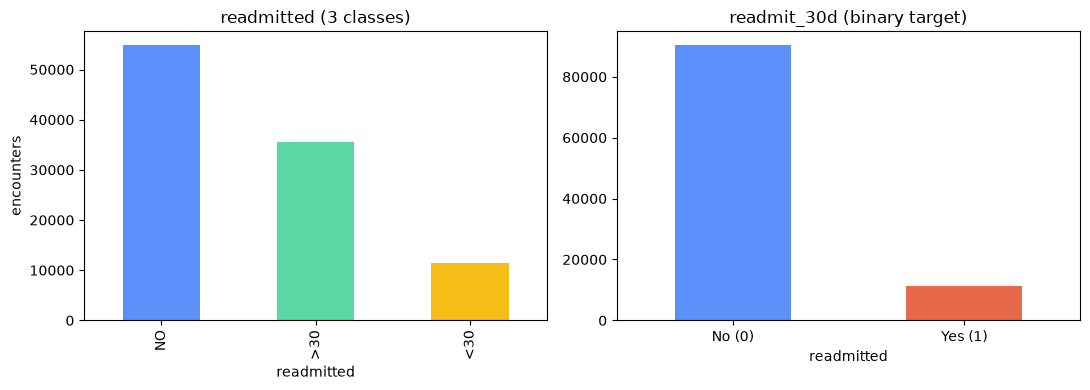

In [3]:
raw_target = (raw["readmitted"] == "<30").astype(int)
counts = raw["readmitted"].value_counts()
print("Raw 'readmitted' distribution:")
print(counts)
print(f"\n30-day readmission positive rate (raw): {raw_target.mean()*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts.plot(kind="bar", ax=ax[0], color=["#5B8FF9", "#5AD8A6", "#F6BD16"])
ax[0].set_title("readmitted (3 classes)"); ax[0].set_ylabel("encounters")
raw_target.value_counts().plot(kind="bar", ax=ax[1], color=["#5B8FF9", "#E8684A"])
ax[1].set_title("readmit_30d (binary target)"); ax[1].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
plt.tight_layout(); plt.show()

### 2b. Missingness
`?` is the dataset's missing token. `weight` (~97% missing) and `payer_code` are dropped; `medical_specialty` is kept but its rare values are bucketed to `Other`.

Columns with missing values (fraction):
weight               96.86 %
medical_specialty    49.08 %
payer_code           39.56 %
race                  2.23 %
diag_3                 1.4 %
diag_2                0.35 %
diag_1                0.02 %
dtype: str


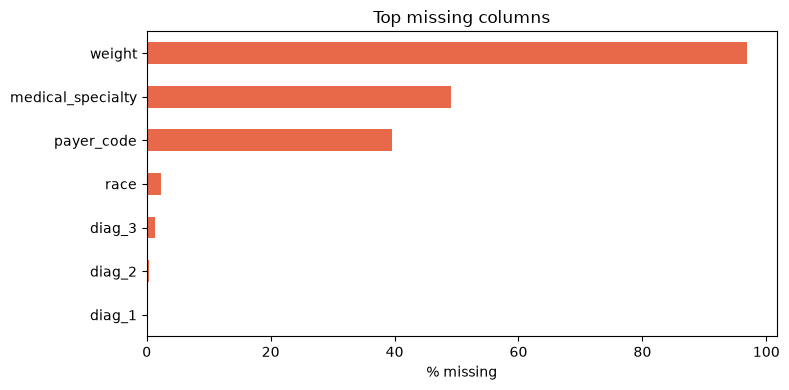

In [4]:
miss = (raw.replace("?", np.nan).isna().mean().sort_values(ascending=False))
miss = miss[miss > 0]
print("Columns with missing values (fraction):")
print((miss * 100).round(2).astype(str) + " %")

miss.head(10).mul(100).plot(kind="barh", color="#E8684A")
plt.gca().invert_yaxis(); plt.xlabel("% missing"); plt.title("Top missing columns")
plt.tight_layout(); plt.show()

## 3. Cleaning (`src/clean.py`)

Each step is a small, unit-tested function. Two are **leakage guards**, not cosmetics:

1. `?` → `NaN` (single missing-value policy)
2. drop near-empty columns (`weight`, `payer_code`)
3. **exclude expired/hospice discharges** - those patients *cannot* be readmitted, so keeping them poisons the label
4. **de-duplicate to the first encounter per patient** - repeated patients would otherwise leak future information across the split
5. cap extreme upper-tail outliers at the 99th percentile
6. standardize: age bucket → ordinal midpoint; `change`/`diabetesMed` → 0/1
7. build the binary target `readmit_30d`

In [5]:
from src.clean import clean

clean_df, stats = clean(raw)
print()
print("De-duplication trade-off (accepted, per plan decision #1):")
print(f"  encounters -> patients : {stats['rows_raw']:,} -> {stats['rows_final']:,}")
print(f"  positive rate          : 11.2%  ->  {stats['positive_rate']*100:.2f}%")
print("  We report this lower, honest positive rate rather than inflating AUROC")
print("  by keeping duplicate encounters.")

Cleaning provenance:
  raw rows                : 101,766
  after expired/hospice   : 99,343 (-2,423)
  after patient dedup     : 69,990 (-29,353)
  final rows              : 69,990
  positive rate (readmit) : 8.98%

De-duplication trade-off (accepted, per plan decision #1):
  encounters -> patients : 101,766 -> 69,990
  positive rate          : 11.2%  ->  8.98%
  We report this lower, honest positive rate rather than inflating AUROC
  by keeping duplicate encounters.


## 4. Feature engineering (`src/features.py`)

The output is a documented **feature schema** (the "contract") that both `CSVSource` and the production `FHIRSource` must honor. Highlights:

- `num_prior_admissions` = inpatient + emergency + outpatient (prior-year utilization - the strongest readmission signal)
- `num_chronic_conditions` = `number_diagnoses`
- **ICD-9 diagnosis grouping** (`diag_1/2/3` → circulatory, respiratory, diabetes, …) per Strack 2014
- lab flags (`A1Cresult`, `max_glu_serum`) and medication churn across the 23 drug columns
- grouped admin fields (admission type/source, discharge disposition)

Nothing here fits a statistic on the data, so it is safe to run before the split - the leakage-prone steps (impute/scale/one-hot) live in the model pipeline and are fit on train only.

Feature engineering:
  numeric features     : 14
  categorical features : 12
  total feature columns: 26
  output shape         : (69990, 29)

Numeric features    : ['age_midpoint', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'num_chronic_conditions', 'num_prior_admissions', 'num_meds_changed', 'num_meds_on', 'change_flag', 'diabetes_med_flag']

Categorical features: ['race', 'gender', 'medical_specialty_grp', 'admission_type_grp', 'admission_source_grp', 'discharge_disposition_grp', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'a1c_result', 'max_glu_serum_grp', 'insulin']


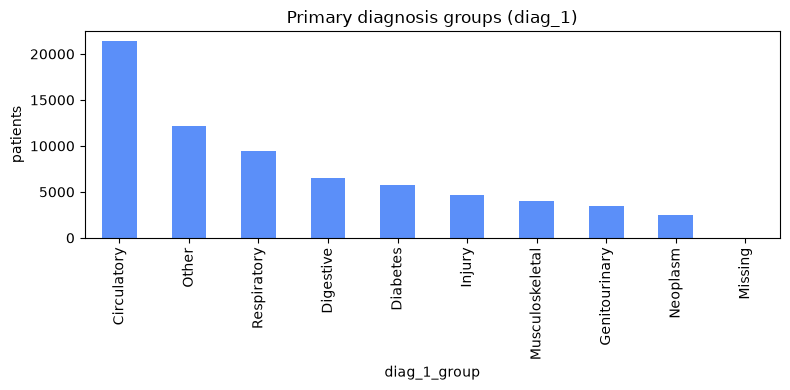

In [6]:
from src.features import build_features

feat_df, schema = build_features(clean_df)
print("\nNumeric features    :", schema.numeric)
print("\nCategorical features:", schema.categorical)

# ICD-9 primary-diagnosis groups (Strack 2014)
ax = feat_df["diag_1_group"].value_counts().plot(kind="bar", color="#5B8FF9")
ax.set_title("Primary diagnosis groups (diag_1)"); ax.set_ylabel("patients")
plt.tight_layout(); plt.show()

## 5. Modeling (`src/model.py`)

- **Split:** stratified 80/20 (seed 42).
- **Pipeline:** one `sklearn.Pipeline` = `ColumnTransformer` (median-impute + scale numerics; most-frequent-impute + one-hot categoricals) + estimator. Preprocessing is fit on **train only**, so there is no leakage and it travels with the serialized model.
- **Models:** `LogisticRegression(class_weight='balanced')` baseline **+** `XGBClassifier(scale_pos_weight=…)` champion, both imbalance-aware.
- **Metrics:** AUROC **and** PR-AUC (imbalance-aware); champion chosen by PR-AUC.

Below we load the metrics produced by `python -m src.model` (rather than retraining inline).

In [7]:
metrics_path = config.MODELS_DIR / "metrics.json"
if not metrics_path.exists():
    from src.model import run
    run()  # trains LR + GBM if artifacts are missing
metrics = json.loads(metrics_path.read_text())

comparison = pd.DataFrame(metrics["models"]).T[
    ["auroc", "pr_auc", "recall", "precision", "f1", "brier"]
]
print(f"Cohort: {metrics['n_rows']:,} patients | positive rate {metrics['positive_rate']*100:.2f}%"
      f" | champion: {metrics['champion'].upper()} ({metrics['gbm_backend']})")
comparison

Cohort: 69,990 patients | positive rate 8.98% | champion: GBM (xgboost)


,auroc,pr_auc,recall,precision,f1,brier
logreg,0.6401,0.1501,0.5267,0.133,0.2124,0.2323
gbm,0.6476,0.1572,0.5314,0.1384,0.2197,0.2152


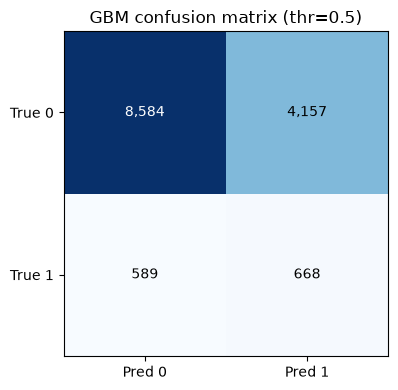

AUROC ~0.65 matches the published literature range (~0.64-0.70) for this
dataset. A far higher score would indicate leakage, not skill.


In [8]:
# Confusion matrix for the champion at the 0.5 threshold
cm = metrics["models"][metrics["champion"]]["confusion_matrix"]
cm_arr = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_arr, cmap="Blues")
for (i, j), v in np.ndenumerate(cm_arr):
    ax.text(j, i, f"{v:,}", ha="center", va="center",
            color="white" if v > cm_arr.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
ax.set_title(f"{metrics['champion'].upper()} confusion matrix (thr=0.5)")
plt.tight_layout(); plt.show()

print("AUROC ~0.65 matches the published literature range (~0.64-0.70) for this")
print("dataset. A far higher score would indicate leakage, not skill.")

## 6. Explainability - SHAP (`src/explain.py`)

Two views:
- **Global:** which features drive readmission risk across the whole panel.
- **Per-patient:** the 3 features contributing most to *that* patient's risk, rendered as human-readable phrases (e.g. "prior inpatient visits: 3"). One-hot columns are aggregated back to their base feature, so a patient's single primary diagnosis is reported once, with the patient's actual value.

Saved global SHAP importance -> /Users/aryamane/Desktop/Hospital_learning/healthcare-ai-projects/patient_risk_stratification_dashboard/outputs/shap_global_importance.png


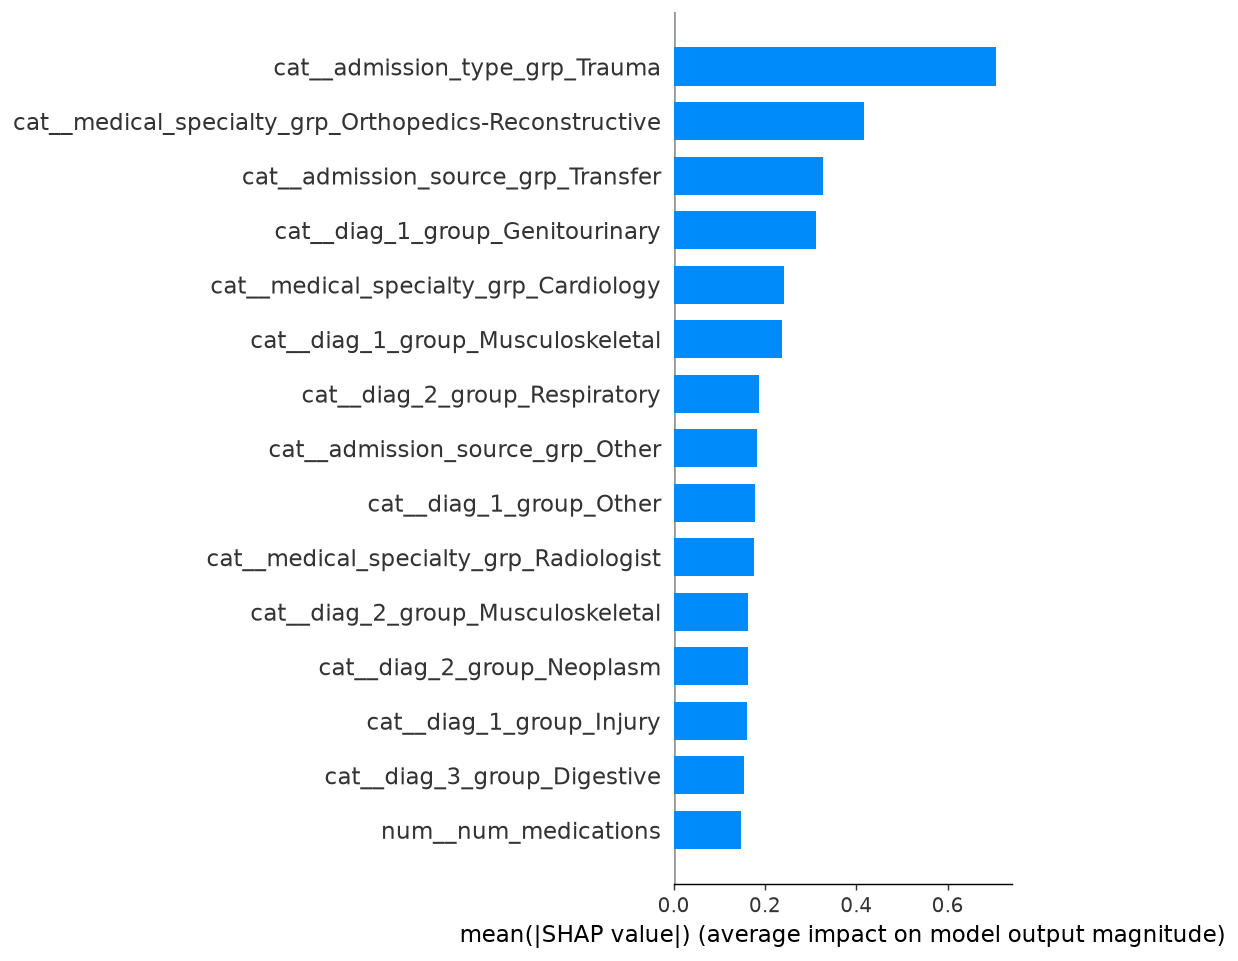

Example per-patient top-3 risk factors:
  - age: 85; insulin: Steady; medication changed this stay: 1
  - procedures: 3; insulin: Steady; lab procedures: 33
  - insulin: Steady; diagnoses on record: 5; medication changed this stay: 1
  - insulin: Steady; days in hospital: 9; prior outpatient visits: 0
  - medications: 16; insulin: Steady; HbA1c
  - medications changed: 1; days in hospital: 7; insulin: Steady


In [9]:
import joblib
from src.explain import explain
from src.model import get_feature_data

pipe = joblib.load(config.MODELS_DIR / "champion_pipeline.joblib")
X, y, ids, _ = get_feature_data()

# Explain a manageable sample for the notebook (full population is scored in export.py)
sample = X.head(1000)
top_factors, shap_matrix, feat_names = explain(pipe, sample, make_global_plot=True, k=3)

from IPython.display import Image, display
display(Image(filename=str(config.OUTPUTS_DIR / "shap_global_importance.png")))

print("Example per-patient top-3 risk factors:")
for t in top_factors[:6]:
    print("  -", t)

## 7. Risk scoring, tiers & the final export (`src/risk_scoring.py`, `src/export.py`)

- `risk_score = round(P(readmit) * 100)` → a 0–100 index.
- **Quantile tiers:** High = top 20% (≥ P80), Medium = P50–P80, Low = < P50. Quantiles guarantee a workable-sized High list; fixed probability cutoffs would leave it empty because this data's probabilities cluster low.
- **Everyone is scored** with **out-of-fold** `cross_val_predict`, so no patient is scored by a model trained on them (honest full-population list for the dashboard).

> Because the champion is imbalance-weighted, the raw `probability` is *adjusted for ranking*, not a calibrated literal frequency. The 0–100 `risk_score` is a **relative** index and the **tiers** are what drive action.

In [10]:
from src.risk_scoring import tier_summary

scores_path = config.OUTPUTS_DIR / "patient_risk_scores.csv"
if not scores_path.exists():
    from src.export import build_export
    build_export()
scores = pd.read_csv(scores_path)

print("Tier distribution:")
print(tier_summary(scores).to_string(index=False))

# score distribution colored by tier
fig, ax = plt.subplots(figsize=(9, 4))
for tier, color in [("Low", "#5AD8A6"), ("Medium", "#F6BD16"), ("High", "#E8684A")]:
    ax.hist(scores.loc[scores.tier == tier, "risk_score"], bins=40,
            alpha=0.7, label=tier, color=color)
ax.set_xlabel("risk_score (0-100)"); ax.set_ylabel("patients"); ax.legend()
ax.set_title("Risk score distribution by tier")
plt.tight_layout(); plt.show()

print("\nTop 5 highest-risk patients:")
scores.head(5)[["patient_id", "risk_score", "tier", "top_3_risk_factors"]]

Tier distribution:
  tier  patients  mean_score  mean_probability  pct_of_panel
  High     14650        64.4            0.6442          20.9
Medium     21038        49.4            0.4944          30.1
   Low     34302        33.2            0.3325          49.0

Top 5 highest-risk patients:


/var/folders/k2/5hcbwx856_z5_q1m7ly2q4mm0000gn/T/ipykernel_84249/3787462311.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


,patient_id,risk_score,tier,top_3_risk_factors
0,111042378,92,High,prior inpatient visits: 3; insulin: Down; prio...
1,97402077,91,High,prior inpatient visits: 3; prior admissions: 3...
2,46993086,90,High,prior inpatient visits: 3; prior admissions: 5...
3,61998570,90,High,prior inpatient visits: 3; prior admissions: 4...
4,50579514,90,High,prior inpatient visits: 2; prior admissions: 2...


## 8. Fairness / bias audit (`src/fairness.py`)

For each protected attribute (race, gender, age band) we report per-subgroup AUROC, recall/TPR, **false-negative rate (FNR)** - high-risk patients *missed*, the most dangerous error for a safety-net tool - and selection rate, plus equal-opportunity and demographic-parity gaps. This feeds the Day-27 Bias Monitoring Panel. Auditing the model, not just shipping it, is the point.

In [11]:
from src.fairness import build_report

report = build_report(verbose=False)
for attr in ("race", "gender", "age_band"):
    if attr in report["tables"]:
        print(f"\n=== {attr} ===")
        display(pd.DataFrame(report["tables"][attr])[
            ["subgroup", "n", "positive_rate", "auroc", "recall_tpr", "fnr", "selection_rate"]
        ])
        print("gaps:", report["gaps"][attr])


=== race ===


,subgroup,n,positive_rate,auroc,recall_tpr,fnr,selection_rate
0,Caucasian,52305,0.0919,0.6449,0.5546,0.4454,0.3595
1,AfricanAmerican,12627,0.0867,0.6379,0.4840,0.5160,0.3084
2,Unknown,1919,0.0735,0.6247,0.4184,0.5816,0.2220
3,Hispanic,1501,0.0813,0.7116,0.5246,0.4754,0.2378
4,Other,1150,0.0687,0.6217,0.3038,0.6962,0.1861
5,Asian,488,0.0840,0.7288,0.4634,0.5366,0.2336


gaps: {'equal_opportunity_diff': 0.2508, 'demographic_parity_diff': 0.1734, 'worst_fnr_subgroup': 'Other', 'worst_fnr': 0.6962}

=== gender ===


,subgroup,n,positive_rate,auroc,recall_tpr,fnr,selection_rate
0,Female,37239,0.0904,0.6511,0.5501,0.4499,0.3511
1,Male,32748,0.0892,0.6397,0.5175,0.4825,0.3277
2,Unknown/Invalid,3,0.0000,NaN,NaN,NaN,0.3333


gaps: {'equal_opportunity_diff': 0.0326, 'demographic_parity_diff': 0.0234, 'worst_fnr_subgroup': 'Male', 'worst_fnr': 0.4825}

=== age_band ===


,subgroup,n,positive_rate,auroc,recall_tpr,fnr,selection_rate
0,70+,30622,0.1040,0.6189,0.6325,0.3675,0.4708
1,50-69,28040,0.0818,0.6580,0.4645,0.5355,0.2667
2,<50,11328,0.0712,0.6510,0.3499,0.6501,0.1687


gaps: {'equal_opportunity_diff': 0.2826, 'demographic_parity_diff': 0.3021, 'worst_fnr_subgroup': '<50', 'worst_fnr': 0.6501}


## 9. Production path & limitations

### Production-ready by design
The model depends only on the `DataSource.load()` contract and the shared feature schema, so swapping the source is one class:
1. **Now (real, historical):** Diabetes 130 via `CSVSource`.
2. **Near-term (live):** `FHIRSource` reusing the Day-14 FHIR pipeline - pull `Patient/Condition/Encounter/Observation`, map to the same schema; nightly batch scores the panel; real-time admits via an HL7 ADT (A01/A03) feed. De-identify before any ML store.
3. **Enterprise:** Epic Caboodle as the batch source; HL7 ADT streaming.

**MLOps rigor already here:** config-driven params, fixed seeds, a serialized pipeline artifact, `metrics.json`, and `pytest` unit tests on `clean.py`/`features.py`.

### Limitations (stated honestly)
- **Modest signal:** AUROC ≈ 0.65 is inherent to this dataset - administrative claims data lacks vitals, labs-over-time, and social determinants that carry much of the readmission signal. We do not overclaim.
- **Uncalibrated probabilities:** imbalance weighting inflates raw probabilities; we use quantile tiers for action and would add `CalibratedClassifierCV` before quoting literal probabilities to clinicians.
- **Population shift:** trained on 1999–2008 diabetic inpatients; a live deployment must re-validate (ideally against an independent cohort such as MIMIC-IV) and monitor drift.
- **Fairness gaps exist** (see §8) - e.g. FNR varies across age bands; the bias panel exists precisely to keep this visible.

### Next (roadmap)
- **Day 26:** Streamlit dashboard (population KPIs, sortable risk table, patient drill-down with SHAP).
- **Day 27:** Claude-generated care plans from each patient's top risk factors + the bias panel.